# Rare Disease Detection with Resampling
## Random Oversampling and SMOTE for beginner-friendly healthcare ML

This notebook is a **second notebook** that goes with the earlier rare disease workflow notebook.

In the earlier notebook, the Logistic Regression model gave results like:

- very high **specificity**
- very low **recall**
- poor detection of true rare disease cases

For example, you saw recall close to **0.033** on the test set and **0.000** on the external validation set.

That means the model was usually saying **"no disease"**, which looks safe mathematically, but is not good clinically if the goal is to **catch rare disease cases**.

## Why are we making this second notebook?

Because in rare disease detection:

- the disease is rare
- the model sees many more negative cases than positive cases
- the model may learn to ignore the minority class

So now we will try two imbalance-handling methods:

1. **Random Oversampling**
2. **SMOTE**

Then we will compare them side by side with the original baseline model.

## Quick reminder from the previous notebook

In the earlier notebook, the baseline Logistic Regression model had this pattern:

| Setting | Threshold | Recall | Specificity | Precision | ROC AUC | PR AUC |
|---|---:|---:|---:|---:|---:|---:|
| Default threshold on test set | 0.5 | 0.033 | 0.997 | 0.333 | 0.846 | 0.257 |
| Chosen clinical threshold on test set | 0.5 | 0.033 | 0.997 | 0.333 | 0.846 | 0.257 |
| External validation | 0.5 | 0.000 | 1.000 | 0.000 | 0.789 | 0.146 |

### What that means in simple words

- The model was excellent at saying **who does not have the disease**
- But it missed almost all of the **true rare disease cases**
- That is why recall was so low

In healthcare, that can be dangerous if missing the disease leads to delayed diagnosis or treatment.

## Step 0: Setup

We will use:

- `numpy` and `pandas` for data
- `matplotlib` and `seaborn` for plots
- `scikit-learn` for Logistic Regression and metrics
- `imblearn` for Random Oversampling and SMOTE

In [1]:
# STEP 0: IMPORT LIBRARIES

try:
    import google.colab
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    !pip -q install numpy pandas matplotlib seaborn scikit-learn imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_curve
)

from imblearn.over_sampling import RandomOverSampler, SMOTE

np.random.seed(42)
sns.set(style="whitegrid")
pd.set_option("display.max_columns", 50)

print("Setup complete. Running in Colab:", IN_COLAB)

Setup complete. Running in Colab: True


## Step 1: Create the same kind of synthetic rare disease data

We will use a similar toy dataset as before so the comparison is easy to understand.

This way, we can focus on one question:

> What changes when we add resampling?

In [2]:
# STEP 1: CREATE SYNTHETIC TOY DATA

n = 4000

group = np.random.choice(["Group A", "Group B"], size=n, p=[0.65, 0.35])

age = np.random.normal(loc=50, scale=15, size=n).clip(18, 90)
symptom_score = np.random.normal(loc=5, scale=2, size=n).clip(0, 10)
lab_score = np.random.normal(loc=100, scale=20, size=n).clip(40, 180)
imaging_score = np.random.normal(loc=3, scale=1.5, size=n).clip(0, 8)
inflammation_marker = np.random.normal(loc=4, scale=2, size=n).clip(0, 15)

risk_score = (
    -7.2
    + 0.025 * age
    + 0.35 * symptom_score
    - 0.018 * lab_score
    + 0.45 * imaging_score
    + 0.20 * inflammation_marker
)

risk_score = np.where(group == "Group B", risk_score + 0.25, risk_score)

disease_probability = 1 / (1 + np.exp(-risk_score))
rare_disease = np.random.binomial(1, disease_probability)

df = pd.DataFrame({
    "age": age,
    "symptom_score": symptom_score,
    "lab_score": lab_score,
    "imaging_score": imaging_score,
    "inflammation_marker": inflammation_marker,
    "group": group,
    "rare_disease": rare_disease
})

df.head()

,age,symptom_score,lab_score,imaging_score,inflammation_marker,group,rare_disease
0,69.929612,3.291013,113.111087,1.412774,0.905443,Group A,0
1,54.697767,4.193868,136.113378,3.586305,1.581155,Group B,0
2,40.902449,5.544473,126.500093,1.740304,2.343589,Group B,0
3,56.838563,4.885459,80.553300,2.233342,4.630619,Group A,0
4,43.113645,6.096134,61.148589,0.000000,4.533652,Group A,0


Class counts:
rare_disease
0    3847
1     153
Name: count, dtype: int64

Class percentages:
rare_disease
0    96.18
1     3.82
Name: proportion, dtype: float64


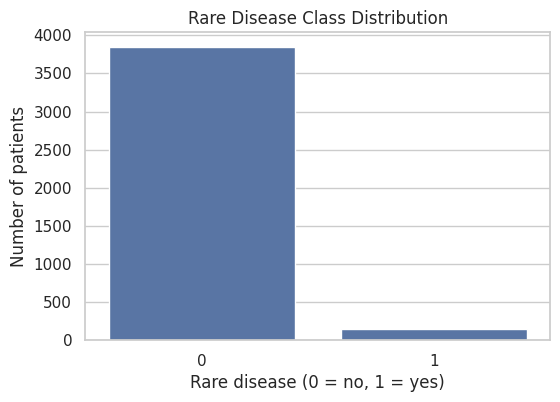

In [3]:
# STEP 1B: CHECK CLASS IMBALANCE

class_counts = df["rare_disease"].value_counts().sort_index()
class_percent = df["rare_disease"].value_counts(normalize=True).sort_index() * 100

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percent.round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="rare_disease")
plt.title("Rare Disease Class Distribution")
plt.xlabel("Rare disease (0 = no, 1 = yes)")
plt.ylabel("Number of patients")
plt.show()

## Step 2: Prepare features and split the data

We will:

- convert the `group` text column to numbers
- split into training, test, and external validation sets

Important rule:

We apply oversampling or SMOTE **only to the training set**.

We do **not** resample the test set or external validation set, because those sets should stay realistic.

In [4]:
# STEP 2: PREPARE DATA

df_model = pd.get_dummies(df, columns=["group"], drop_first=True)

X = df_model.drop(columns=["rare_disease"])
y = df_model["rare_disease"]

X_temp, X_external, y_temp, y_external = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("External validation set shape:", X_external.shape)

Training set shape: (2400, 6)
Test set shape: (800, 6)
External validation set shape: (800, 6)


## Step 3: Build a simple evaluation function

We will compare models using healthcare-friendly metrics:

- Accuracy
- Precision
- Recall
- Specificity
- F1-score
- ROC AUC
- PR AUC

For rare disease detection, **Recall** and **PR AUC** are especially important.

In [5]:
# STEP 3: EVALUATION FUNCTION

def evaluate_model(y_true, y_prob, threshold=0.50):
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = f1_score(y_true, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)

    return pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"],
        "Value": [accuracy, precision, recall, specificity, f1, roc_auc, pr_auc]
    }), (tn, fp, fn, tp), y_pred

## Step 4: Train the baseline model with no resampling

In [6]:
# STEP 4: BASELINE MODEL

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

baseline_test_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_external_prob = baseline_model.predict_proba(X_external)[:, 1]

baseline_test_results, baseline_test_cm, baseline_test_pred = evaluate_model(y_test, baseline_test_prob, threshold=0.50)
baseline_external_results, baseline_external_cm, baseline_external_pred = evaluate_model(y_external, baseline_external_prob, threshold=0.50)

print("Baseline model results on test set:")
display(baseline_test_results)

print("Baseline model results on external validation set:")
display(baseline_external_results)

Baseline model results on test set:


,Metric,Value
0,Accuracy,0.961250
1,Precision,0.333333
2,Recall,0.033333
3,Specificity,0.997403
4,F1-score,0.060606
5,ROC AUC,0.846104
6,PR AUC,0.257161


Baseline model results on external validation set:


,Metric,Value
0,Accuracy,0.961250
1,Precision,0.000000
2,Recall,0.000000
3,Specificity,1.000000
4,F1-score,0.000000
5,ROC AUC,0.788791
6,PR AUC,0.145921


## Why baseline recall is often poor in rare disease tasks

The training data contain many more negative cases than positive cases.

So the model may learn this shortcut:

> "If I predict negative for most people, I will usually be right."

That can produce:

- high accuracy
- high specificity
- low recall

## Step 5: Random Oversampling

Random Oversampling simply **copies minority class examples** in the training data until the classes are more balanced.

In [7]:
# STEP 5: RANDOM OVERSAMPLING

ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Original training class counts:")
print(y_train.value_counts())

print("\nRandom oversampled training class counts:")
print(y_train_ros.value_counts())

Original training class counts:
rare_disease
0    2308
1      92
Name: count, dtype: int64

Random oversampled training class counts:
rare_disease
0    2308
1    2308
Name: count, dtype: int64


In [8]:
# STEP 5B: TRAIN MODEL AFTER RANDOM OVERSAMPLING

ros_model = LogisticRegression(max_iter=1000)
ros_model.fit(X_train_ros, y_train_ros)

ros_test_prob = ros_model.predict_proba(X_test)[:, 1]
ros_external_prob = ros_model.predict_proba(X_external)[:, 1]

ros_test_results, ros_test_cm, ros_test_pred = evaluate_model(y_test, ros_test_prob, threshold=0.50)
ros_external_results, ros_external_cm, ros_external_pred = evaluate_model(y_external, ros_external_prob, threshold=0.50)

print("Random Oversampling results on test set:")
display(ros_test_results)

print("Random Oversampling results on external validation set:")
display(ros_external_results)

Random Oversampling results on test set:


,Metric,Value
0,Accuracy,0.732500
1,Precision,0.110169
2,Recall,0.866667
3,Specificity,0.727273
4,F1-score,0.195489
5,ROC AUC,0.846970
6,PR AUC,0.261440


Random Oversampling results on external validation set:


,Metric,Value
0,Accuracy,0.722500
1,Precision,0.097046
2,Recall,0.741935
3,Specificity,0.721717
4,F1-score,0.171642
5,ROC AUC,0.791099
6,PR AUC,0.143732


## Step 6: SMOTE

SMOTE creates **new synthetic minority examples** instead of exact copies.

In [9]:
# STEP 6: SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Original training class counts:")
print(y_train.value_counts())

print("\nSMOTE training class counts:")
print(y_train_smote.value_counts())

Original training class counts:
rare_disease
0    2308
1      92
Name: count, dtype: int64

SMOTE training class counts:
rare_disease
0    2308
1    2308
Name: count, dtype: int64


In [10]:
# STEP 6B: TRAIN MODEL AFTER SMOTE

smote_model = LogisticRegression(max_iter=1000)
smote_model.fit(X_train_smote, y_train_smote)

smote_test_prob = smote_model.predict_proba(X_test)[:, 1]
smote_external_prob = smote_model.predict_proba(X_external)[:, 1]

smote_test_results, smote_test_cm, smote_test_pred = evaluate_model(y_test, smote_test_prob, threshold=0.50)
smote_external_results, smote_external_cm, smote_external_pred = evaluate_model(y_external, smote_external_prob, threshold=0.50)

print("SMOTE results on test set:")
display(smote_test_results)

print("SMOTE results on external validation set:")
display(smote_external_results)

SMOTE results on test set:


,Metric,Value
0,Accuracy,0.747500
1,Precision,0.098131
2,Recall,0.700000
3,Specificity,0.749351
4,F1-score,0.172131
5,ROC AUC,0.834286
6,PR AUC,0.234801


SMOTE results on external validation set:


,Metric,Value
0,Accuracy,0.765000
1,Precision,0.101523
2,Recall,0.645161
3,Specificity,0.769831
4,F1-score,0.175439
5,ROC AUC,0.775788
6,PR AUC,0.135069


## Step 7: Side-by-side comparison on the test set

Now we compare all three training approaches:

1. Baseline
2. Random Oversampling
3. SMOTE

In [11]:
# STEP 7: SIDE-BY-SIDE COMPARISON ON TEST SET

def results_to_dict(results_df):
    return results_df.set_index("Metric")["Value"].to_dict()

baseline_test_dict = results_to_dict(baseline_test_results)
ros_test_dict = results_to_dict(ros_test_results)
smote_test_dict = results_to_dict(smote_test_results)

comparison_test = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"],
    "Baseline": [baseline_test_dict[m] for m in ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"]],
    "Random Oversampling": [ros_test_dict[m] for m in ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"]],
    "SMOTE": [smote_test_dict[m] for m in ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"]],
})

display(comparison_test.round(3))

,Metric,Baseline,Random Oversampling,SMOTE
0,Accuracy,0.961,0.732,0.748
1,Precision,0.333,0.110,0.098
2,Recall,0.033,0.867,0.700
3,Specificity,0.997,0.727,0.749
4,F1-score,0.061,0.195,0.172
5,ROC AUC,0.846,0.847,0.834
6,PR AUC,0.257,0.261,0.235


In [ ]:
# STEP 7B: SIDE-BY-SIDE COMPARISON ON EXTERNAL VALIDATION SET

baseline_external_dict = results_to_dict(baseline_external_results)
ros_external_dict = results_to_dict(ros_external_results)
smote_external_dict = results_to_dict(smote_external_results)

comparison_external = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"],
    "Baseline": [baseline_external_dict[m] for m in ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"]],
    "Random Oversampling": [ros_external_dict[m] for m in ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"]],
    "SMOTE": [smote_external_dict[m] for m in ["Accuracy", "Precision", "Recall", "Specificity", "F1-score", "ROC AUC", "PR AUC"]],
})

display(comparison_external.round(3))

## What changes should you expect?

Often, after Random Oversampling or SMOTE:

- **Recall increases**
- **Specificity may decrease**
- **Precision may go up or down**
- **PR AUC may improve**

This is a trade-off.

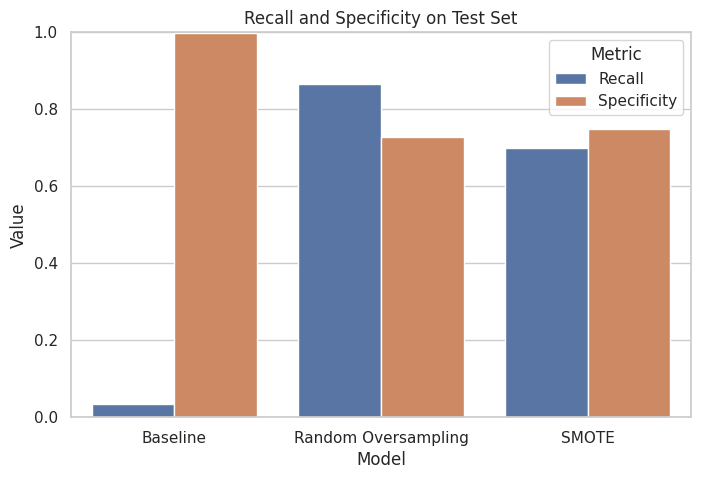

In [12]:
# STEP 7C: BAR CHART FOR RECALL AND SPECIFICITY ON TEST SET

plot_df = pd.DataFrame({
    "Model": ["Baseline", "Random Oversampling", "SMOTE"],
    "Recall": [baseline_test_dict["Recall"], ros_test_dict["Recall"], smote_test_dict["Recall"]],
    "Specificity": [baseline_test_dict["Specificity"], ros_test_dict["Specificity"], smote_test_dict["Specificity"]],
})

plot_df_melt = plot_df.melt(id_vars="Model", value_vars=["Recall", "Specificity"],
                            var_name="Metric", value_name="Value")

plt.figure(figsize=(8, 5))
sns.barplot(data=plot_df_melt, x="Model", y="Value", hue="Metric")
plt.title("Recall and Specificity on Test Set")
plt.ylim(0, 1)
plt.show()

## Step 8: Compare confusion matrices

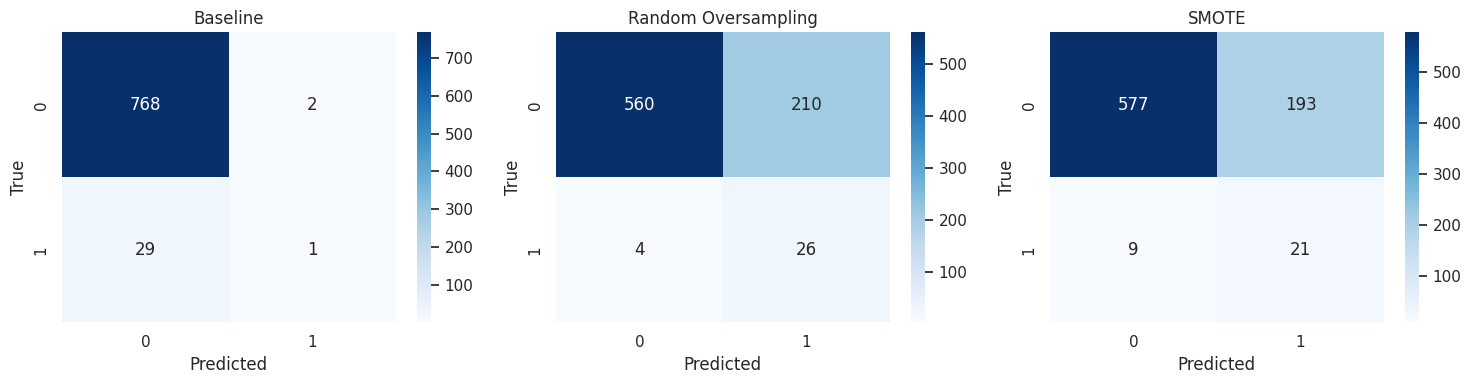

In [13]:
# STEP 8: PLOT CONFUSION MATRICES

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cms = [
    ("Baseline", confusion_matrix(y_test, baseline_test_pred)),
    ("Random Oversampling", confusion_matrix(y_test, ros_test_pred)),
    ("SMOTE", confusion_matrix(y_test, smote_test_pred)),
]

for ax, (title, cm) in zip(axes, cms):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.show()

## Step 9: Compare Precision-Recall curves

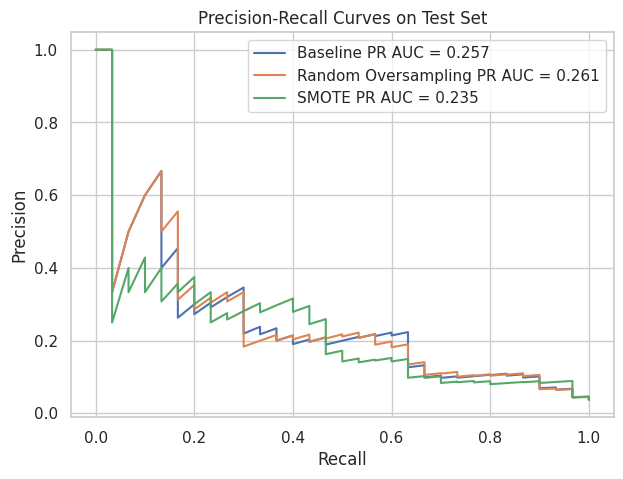

In [14]:
# STEP 9: PRECISION-RECALL CURVES

baseline_precision, baseline_recall, _ = precision_recall_curve(y_test, baseline_test_prob)
ros_precision, ros_recall, _ = precision_recall_curve(y_test, ros_test_prob)
smote_precision, smote_recall, _ = precision_recall_curve(y_test, smote_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(baseline_recall, baseline_precision, label=f"Baseline PR AUC = {average_precision_score(y_test, baseline_test_prob):.3f}")
plt.plot(ros_recall, ros_precision, label=f"Random Oversampling PR AUC = {average_precision_score(y_test, ros_test_prob):.3f}")
plt.plot(smote_recall, smote_precision, label=f"SMOTE PR AUC = {average_precision_score(y_test, smote_test_prob):.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves on Test Set")
plt.legend()
plt.show()

## Step 10: Compare ROC curves

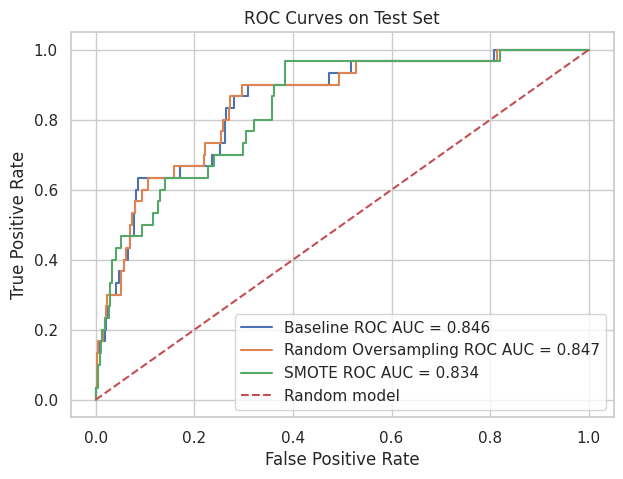

In [15]:
# STEP 10: ROC CURVES

baseline_fpr, baseline_tpr, _ = roc_curve(y_test, baseline_test_prob)
ros_fpr, ros_tpr, _ = roc_curve(y_test, ros_test_prob)
smote_fpr, smote_tpr, _ = roc_curve(y_test, smote_test_prob)

plt.figure(figsize=(7, 5))
plt.plot(baseline_fpr, baseline_tpr, label=f"Baseline ROC AUC = {roc_auc_score(y_test, baseline_test_prob):.3f}")
plt.plot(ros_fpr, ros_tpr, label=f"Random Oversampling ROC AUC = {roc_auc_score(y_test, ros_test_prob):.3f}")
plt.plot(smote_fpr, smote_tpr, label=f"SMOTE ROC AUC = {roc_auc_score(y_test, smote_test_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Set")
plt.legend()
plt.show()

## Step 11: Simple final interpretation

Use the results to answer these questions:

1. Which model catches more true rare disease cases?
2. Which model keeps false positives lower?
3. Which model has better PR AUC?
4. Which model would be safer if missed disease is very costly?

There is no single perfect answer.

In healthcare, the "best" model depends on the clinical goal.

In [16]:
# STEP 11: SIMPLE FINAL SUMMARY TEXT

best_recall_model = plot_df.sort_values(by="Recall", ascending=False).iloc[0]["Model"]
best_specificity_model = plot_df.sort_values(by="Specificity", ascending=False).iloc[0]["Model"]

print("Model with highest recall on test set:", best_recall_model)
print("Model with highest specificity on test set:", best_specificity_model)

print("\nBeginner-friendly interpretation:")
print("- The baseline model may look strong on specificity, but it can miss many true disease cases.")
print("- Random Oversampling and SMOTE are used because the disease is rare and the model needs more minority-class examples during training.")
print("- If recall improves after resampling, that means the model is catching more true rare disease cases.")
print("- If specificity drops, that means the model may create more false alarms.")
print("- In healthcare, this trade-off must be judged clinically, not only mathematically.")

Model with highest recall on test set: Random Oversampling
Model with highest specificity on test set: Baseline

Beginner-friendly interpretation:
- The baseline model may look strong on specificity, but it can miss many true disease cases.
- Random Oversampling and SMOTE are used because the disease is rare and the model needs more minority-class examples during training.
- If recall improves after resampling, that means the model is catching more true rare disease cases.
- If specificity drops, that means the model may create more false alarms.
- In healthcare, this trade-off must be judged clinically, not only mathematically.


## Final insight

We created this second notebook because the first notebook showed a common rare-disease problem:

- very low recall
- almost no positive predictions
- poor detection of true disease cases

That is why we tried:

- **Random Oversampling**
- **SMOTE**

These methods do not magically solve everything, but they often help the model pay more attention to the rare disease class.

If the disease is serious and missing it is harmful, a model with:

- higher recall
- acceptable precision
- acceptable false-positive burden

may be more useful than a model that simply predicts "no disease" most of the time.